# Examen Final — Programación 1 (F12)
## Análisis de Datos Sísmicos con la API del USGS

**Nombre:** Maria de los Angeles Rojas Granizo  
**Carnet:** 202500859  
**Fecha:** 17/05/2026  
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos con `pd.read_csv()` desde URL | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el sismo más intenso con un ciclo `for` | 10 |
| 2b | Top 5 sismos más profundos con pandas | 10 |
| 3a | Función `clasificar_sismo()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_sismos()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: ¿Qué es un terremoto y cómo se mide?

Un **terremoto** ocurre cuando dos placas tectónicas se deslizan bruscamente entre sí,
liberando energía en forma de ondas sísmicas que se propagan por la tierra.

### Magnitud — escala de intensidad

La magnitud mide la energía liberada. La relación es **logarítmica**:
un sismo de magnitud 7.0 libera ~32 veces más energía que uno de 6.0.

| Magnitud | Categoría | Frecuencia aproximada (global) |
|---|---|---|
| < 5.5 | Ligero | Miles por año |
| 5.5 – 5.9 | Moderado-Fuerte | ~500 por año |
| 6.0 – 6.9 | Fuerte | ~130 por año |
| 7.0 – 7.9 | Mayor | ~15 por año |
| ≥ 8.0 | Gran terremoto | 1–2 por año |

### Profundidad del foco

La **profundidad** (columna `depth`) indica dónde ocurrió la ruptura:
- **Superficial** (< 70 km): generalmente más destructivo
- **Intermedio** (70–300 km): daños moderados
- **Profundo** (> 300 km): raramente destructivo en superficie


---
## El dataset: USGS Earthquake Catalog

**Fuente:** United States Geological Survey — [earthquake.usgs.gov](https://earthquake.usgs.gov)

El USGS monitorea la actividad sísmica global en tiempo real y publica todos los
registros de forma abierta. Su API permite descargar datos históricos directamente
como CSV, **sin necesidad de API key**.

Los datos de este examen contienen todos los sismos de **magnitud ≥ 5.5 registrados
en el primer semestre de 2024** (aproximadamente 700 eventos).

### Columnas principales

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | str | Fecha y hora UTC del evento |
| `mag` | float | Magnitud del sismo |
| `depth` | float | Profundidad del foco en kilómetros |
| `magType` | str | Escala usada (`mww`, `mb`, `ml`, …) |
| `place` | str | Descripción de la ubicación |
| `latitude` | float | Latitud del epicentro |
| `longitude` | float | Longitud del epicentro |

### URL del dataset

```
https://earthquake.usgs.gov/fdsnws/event/1/query
    ?format=csv
    &starttime=2024-01-01
    &endtime=2024-06-30
    &minmagnitude=5.5
```

> `pd.read_csv()` acepta URLs directamente — no necesitas descargar el archivo.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL_SISMOS = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2024-06-30"
    "&minmagnitude=5.5"
)

print("Librerias importadas correctamente.")
print(f"URL: {URL_SISMOS}")


Librerias importadas correctamente.
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2024-01-01&endtime=2024-06-30&minmagnitude=5.5


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [18]:
# Completa tus datos
NOMBRE = "Maria de los Angeles Rojas Granizo"   # TU NOMBRE AQUI
CARNET = "202500859"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Maria de los Angeles Rojas Granizo
Carnet     : 202500859


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar el CSV desde la URL (10 pts)

`pandas.read_csv()` puede cargar datos directamente desde una URL,
igual que desde un archivo local. El resultado es un **DataFrame**.

Carga los datos usando `URL_SISMOS` (ya definida arriba) y guárdalos en la
variable `sismos`. Luego muestra:
- Las primeras 5 filas con `.head()`
- Las dimensiones con `.shape`
- Los tipos de datos con `.dtypes`
- Los valores nulos con `.isnull().sum()`


In [19]:
# Carga el CSV desde URL_SISMOS con pd.read_csv() y guárdalo en 'sismos'
sismos = ...  # TU CÓDIGO AQUÍ
sismos = pd.read_csv(URL_SISMOS)

# Muestra las primeras 5 filas
# TU CÓDIGO AQUÍ
print(sismos.head())

# Muestra las dimensiones (shape)
# TU CÓDIGO AQUÍ
print("\nDimensiones del DataFrame:")
print(sismos.shape)

# Muestra los tipos de datos (dtypes)
# TU CÓDIGO AQUÍ
print("\nTipos de datos por columna:")
print(sismos.dtypes)

# Verifica valores nulos con isnull().sum()
# TU CÓDIGO AQUÍ
print("\nValores nulos por columna:")
print(sismos.isnull().sum())


                       time  latitude  longitude  depth  mag magType    nst  \
0  2024-06-29T16:38:46.516Z  -54.0633     7.2302   10.0  5.6     mww  209.0   
1  2024-06-29T07:05:32.855Z  -16.0485   -74.5560   18.0  6.1     mww  138.0   
2  2024-06-28T13:00:39.570Z  -20.6490  -175.6315   10.0  5.7     mww   75.0   
3  2024-06-28T05:36:36.902Z  -15.8277   -74.4540   24.0  7.2     mww  105.0   
4  2024-06-27T16:37:51.299Z  -33.4081  -179.2724   29.0  5.9     mww   95.0   

    gap    dmin   rms  ...                   updated  \
0  16.0  18.209  0.88  ...  2024-09-04T21:57:44.040Z   
1  89.0   4.606  0.71  ...  2024-09-04T21:57:44.040Z   
2  38.0   0.654  0.65  ...  2024-10-09T03:15:27.209Z   
3  46.0   4.675  0.93  ...  2025-02-09T14:16:45.954Z   
4  56.0   4.292  1.05  ...  2024-09-04T21:57:42.040Z   

                           place        type horizontalError depthError  \
0           Bouvet Island region  earthquake            8.89      1.193   
1     34 km SW of Atiquipa, Peru  eart

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y el método
[`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html),
imprime la información de los **primeros 5 sismos** en este formato:

```
Sismo 1: mag=6.10 | prof=35.0 km | lugar=Southern Sumatra, Indonesia
Sismo 2: mag=5.80 | prof=10.0 km | lugar=...
...
```

> **¿Por qué iterar sobre un DataFrame?**  
> Aunque pandas vectoriza la mayoría de operaciones, los ciclos `for` sobre filas
> son útiles cuando necesitas lógica condicional compleja por fila o procesar
> cada elemento de forma independiente.


In [20]:
# Hint: .iterrows() devuelve pares (indice, fila) donde 'fila' es una Serie
# Hint: accede a los valores con fila['mag'], fila['depth'], fila['place']
# Hint: usa enumerate() o un contador para detener el ciclo en 5

contador = 0
for indice, fila in sismos.iterrows():
    if contador >= 5:
        break
    # TU CÓDIGO AQUÍ — imprime mag, depth y place de esta fila
    print(f"Sismo {contador + 1}: mag={fila['mag']:.2f} | prof={fila['depth']:.1f} km | lugar={fila['place']}")


    contador += 1


Sismo 1: mag=5.60 | prof=10.0 km | lugar=Bouvet Island region
Sismo 2: mag=6.10 | prof=18.0 km | lugar=34 km SW of Atiquipa, Peru
Sismo 3: mag=5.70 | prof=10.0 km | lugar=67 km NNW of Houma, Tonga
Sismo 4: mag=7.20 | prof=24.0 km | lugar=10 km WSW of Atiquipa, Peru
Sismo 5: mag=5.90 | prof=29.0 km | lugar=south of the Kermadec Islands


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Sismo más intenso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna `mag`
y encuentra el sismo con la **mayor magnitud**.
Guarda el índice y la magnitud máxima encontrada, luego imprime los datos
completos de ese sismo (place, mag, depth, magType).

### Parte b) — Top 5 más profundos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 sismos más profundos**.
Muestra solo las columnas `place`, `mag`, `depth` y `magType`.
Luego verifica que el sismo encontrado en la Parte a) aparece en el top 5
de magnitudes (usa también `.sort_values()` + `.head()`).


In [21]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   mag_max   = 0     (para ir guardando el mayor encontrado)
#   idx_max   = None  (para recordar el índice de esa fila)

mag_max = 0
idx_max = None

for idx, mag in enumerate(sismos['mag']):
    # TU CÓDIGO AQUÍ — actualiza mag_max e idx_max si encontraste uno mayor
    if mag > mag_max:
        mag_max = mag
        idx_max = idx

    pass


print("Sismo más intenso:")
print(sismos.loc[idx_max, ['place', 'mag', 'depth', 'magType']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 sismos más profundos:")
# TU CÓDIGO AQUÍ — sort_values por 'depth' descendente + head(5)
top_profundos = sismos.sort_values(by='depth', ascending=False).head(5)
print(top_profundos[['place', 'mag', 'depth', 'magType']])

print("\nTop 5 sismos de mayor magnitud:")
# TU CÓDIGO AQUÍ — sort_values por 'mag' descendente + head(5)
top_magnitud = sismos.sort_values(by='mag', ascending=False).head(5)
print(top_magnitud[['place', 'mag', 'depth', 'magType']])


Sismo más intenso:
place      2024 Noto Peninsula, Japan Earthquake
mag                                          7.5
depth                                       10.0
magType                                      mww
Name: 181, dtype: object

Top 5 sismos más profundos:
                                     place  mag    depth magType
149            70 km W of Tarauacá, Brazil  6.5  621.081     mww
25                          Sea of Okhotsk  5.9  619.618     mww
158          123 km NW of Tarauacá, Brazil  6.6  607.000     mww
29                231 km E of Levuka, Fiji  5.5  603.306     mww
104  125 km NNW of Kimbe, Papua New Guinea  5.6  570.902     mww

Top 5 sismos de mayor magnitud:
                                      place  mag   depth magType
181   2024 Noto Peninsula, Japan Earthquake  7.5  10.000     mww
98          15 km S of Hualien City, Taiwan  7.4  40.000     mww
3               10 km WSW of Atiquipa, Peru  7.2  24.000     mww
156              128 km WNW of Aykol, China  7.0

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos sismos tiene tu dataset?** 183 sismos   
   **¿Cuál fue la magnitud máxima registrada?** 7.5  
   **¿En qué lugar ocurrió ese sismo?** 2024 Noto Peninsula, Japan Earthquake

2. **¿Cuál fue el sismo más profundo?**  
   Lugar: 70 km W of Tarauacá, Brazil  | Profundidad: 621.081 km | Magnitud: 6.5  
   Según la clasificación (< 70 km superficial, 70–300 km intermedio, > 300 km profundo),
   ¿de qué tipo fue? Fue de tipo "Profundo".    
   ¿Esperarías que ese sismo fuera muy destructivo en superficie? Justifica en una oración.

   *Tu respuesta:* No, porque al ocurrir a tanta profundidad (más de 300 km), la energía de las ondas sísmicas se disipa significativamente antes de alcanzar la superficie terrestre.

3. ¿El sismo más intenso y el más profundo son el mismo evento?  
   ¿Qué te dice eso sobre la relación entre magnitud y profundidad?

   *Tu respuesta:* No son el mismo evento; esto demuestra que la magnitud (energía liberada) y la profundidad del foco son variables independientes, por lo que un sismo muy profundo puede ser de baja magnitud y viceversa.


---
## Ejercicio 3 — Clasificar sismos con condicionales (25 pts)

### Parte a) — Función `clasificar_sismo(mag)` (15 pts)

Escribe una función que reciba la magnitud (float) y retorne la categoría
según la siguiente escala:

| Magnitud | Categoría |
|---|---|
| 5.5 ≤ mag < 6.0 | `'Moderado-Fuerte'` |
| 6.0 ≤ mag < 7.0 | `'Fuerte'` |
| 7.0 ≤ mag < 8.0 | `'Mayor'` |
| mag ≥ 8.0 | `'Gran terremoto'` |

> **Nota:** la magnitud es un float (ej. 6.73). Puedes comparar directamente
> con `if mag < 6.0:` sin necesidad de convertir a entero.

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'categoria'` al DataFrame `sismos`.
Luego usa `.groupby('categoria')` para contar cuántos sismos hay en cada
categoría e imprime el resultado.


In [22]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_sismo(mag):
    """Clasifica la intensidad de un sismo según su magnitud."""
    # TU CÓDIGO AQUÍ
    if mag < 6.0:
        return 'Moderado-Fuerte'
    elif mag < 7.0:
        return 'Fuerte'
    elif mag < 8.0:
        return 'Mayor'
    else:
        return 'Gran terremoto'
    
    pass


# Prueba tu función — verifica que los resultados son correctos:
for mag_prueba in [5.6, 5.9, 6.0, 6.5, 7.0, 7.8, 8.1]:
    print(f"  mag={mag_prueba:.1f}  →  {clasificar_sismo(mag_prueba)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply() para crear la columna 'categoria'
#   sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

# TU CÓDIGO AQUÍ — agregar columna 'categoria'
sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

# TU CÓDIGO AQUÍ — groupby('categoria') para contar sismos por categoría
#   y mostrar el resultado ordenado
print("\nConteo de sismos por categoría:")
conteo_categorias = sismos.groupby('categoria').size().sort_values(ascending=False)
print(conteo_categorias)


  mag=5.6  →  Moderado-Fuerte
  mag=5.9  →  Moderado-Fuerte
  mag=6.0  →  Fuerte
  mag=6.5  →  Fuerte
  mag=7.0  →  Mayor
  mag=7.8  →  Mayor
  mag=8.1  →  Gran terremoto

Conteo de sismos por categoría:
categoria
Moderado-Fuerte    132
Fuerte              47
Mayor                4
dtype: int64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad | % del total |
   |---|---|---|
   | Moderado-Fuerte | 132 | 72 % |
   | Fuerte | 47 | 26 % |
   | Mayor | 4 | 2 % |
   | Gran terremoto | 0 | 0 % |

2. ¿Qué categoría predomina en tu dataset? ¿Tiene sentido físicamente,
   considerando que la frecuencia de sismos disminuye con la magnitud?

   *Tu respuesta:* Predomina la categoría 'Moderado-Fuerte'; sí tiene sentido físico porque la liberación de energía sísmica sigue una distribución logarítmica, donde los eventos de menor magnitud son exponencialmente más frecuentes que los grandes terremotos.

3. ¿Tu dataset contiene algún `'Gran terremoto'` (magnitud ≥ 8.0)?
   Si sí, ¿en qué región ocurrió? Si no, ¿es eso esperable para un semestre?

   *Tu respuesta:* No contiene ninguno. Es un resultado completamente esperable para un periodo de un solo semestre, ya que estadísticamente los sismos de magnitud $\ge$ 8.0 ocurren únicamente entre 1 y 2 veces por año a nivel global.


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_sismos(df)` (15 pts)

Escribe una función que reciba el DataFrame `sismos` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total'` | número total de sismos |
| `'mag_media'` | magnitud promedio (redondeada a 2 decimales) |
| `'mag_max'` | magnitud máxima registrada |
| `'prof_media'` | profundidad promedio en km (redondeada a 1 decimal) |
| `'tipo_mas_comun'` | valor de `magType` con más registros |
| `'grandes_terremotos'` | cantidad de sismos con magnitud ≥ 7.0 |

Luego llama la función con `sismos` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas** (en celdas separadas o en la misma). Cada una debe tener
título y etiquetas en ambos ejes:

1. **Histograma** de magnitudes (usa al menos 15 intervalos)
2. **Scatter plot**: profundidad (`depth`) vs magnitud (`mag`),
   coloreado por `categoria` (usa `hue='categoria'` en seaborn)
3. **Gráfica de barras**: cantidad de sismos por tipo de escala (`magType`)


In [23]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max() sobre las columnas del DataFrame
# Hint: para 'tipo_mas_comun' usa .value_counts().index[0]
# Hint: para 'grandes_terremotos' puedes usar (df['mag'] >= 7.0).sum()
#       o un ciclo for con condicional

def analizar_sismos(df):
    """
    Resume las estadísticas principales del dataset sísmico.

    Parámetro:
        df (DataFrame): el DataFrame de sismos.

    Retorna:
        dict con las claves: total, mag_media, mag_max, prof_media,
                             tipo_mas_comun, grandes_terremotos.
    """
    resultado = {
        "total": len(df), # TU CÓDIGO AQUÍ 
        "mag_media": round(df['mag'].mean(), 2), # TU CÓDIGO AQUÍ 
        "mag_max": df['mag'].max(), # TU CÓDIGO AQUÍ
        "prof_media": round(df['depth'].mean(), 1), # TU CÓDIGO AQUÍ
        "tipo_mas_comun": df['magType'].value_counts().index[0], # TU CÓDIGO AQUÍ
        "grandes_terremotos": (df['mag'] >= 7.0).sum(), # TU CÓDIGO AQUÍ
    }
    return resultado


# Llama la función e imprime el resumen
resumen = analizar_sismos(sismos)
for clave, valor in resumen.items():
    print(f"  {clave:<22}: {valor}")


  total                 : 183
  mag_media             : 5.85
  mag_max               : 7.5
  prof_media            : 64.1
  tipo_mas_comun        : mww
  grandes_terremotos    : 4


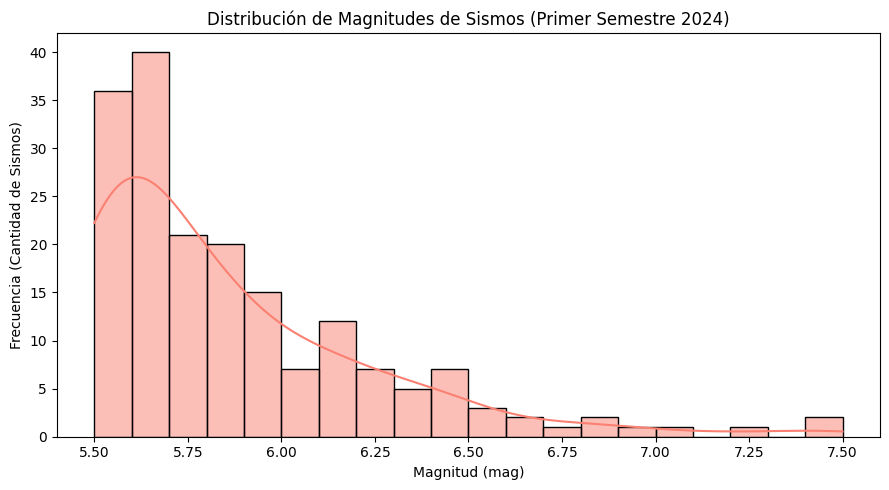

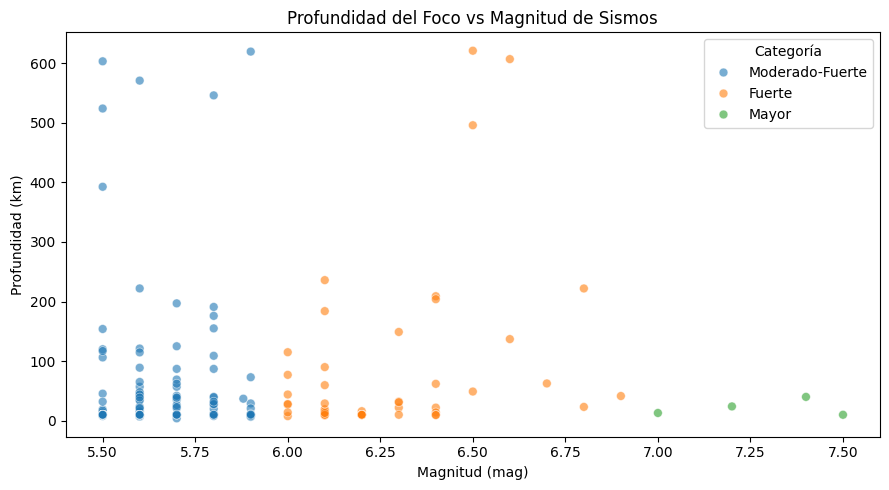

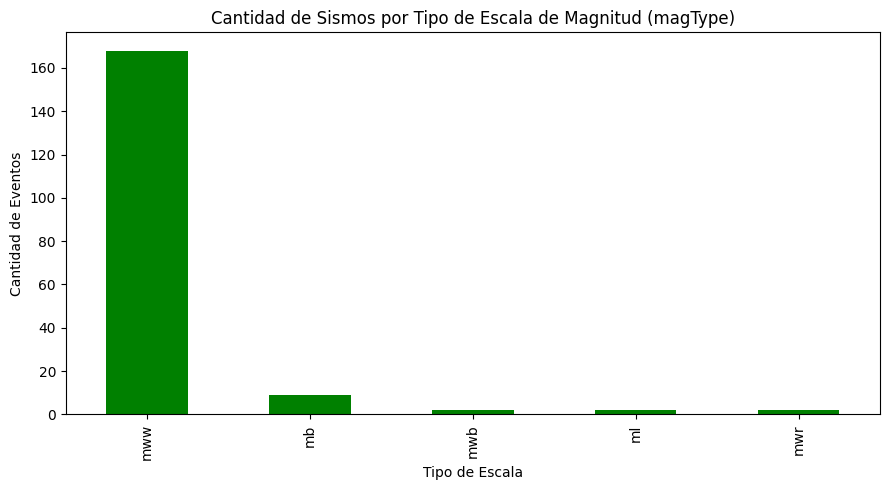

In [24]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: Histograma de magnitudes
plt.figure(figsize=(9, 5))
# Hint: sns.histplot(data=sismos, x='mag', bins=20, kde=True, color='royalblue')
# TU CÓDIGO AQUÍ
sns.histplot(data=sismos, x='mag', bins=20, kde=True, color='salmon')
plt.title("Distribución de Magnitudes de Sismos (Primer Semestre 2024)")
plt.xlabel("Magnitud (mag)")
plt.ylabel("Frecuencia (Cantidad de Sismos)")
plt.tight_layout()
plt.show()


# Gráfica 2: Scatter profundidad vs magnitud coloreado por categoría
plt.figure(figsize=(9, 5))
# Hint: sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)
# TU CÓDIGO AQUÍ 
sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)
plt.title("Profundidad del Foco vs Magnitud de Sismos")
plt.xlabel("Magnitud (mag)")
plt.ylabel("Profundidad (km)")
plt.legend(title="Categoría")
plt.tight_layout()
plt.show()


# Gráfica 3: Barras — cantidad de sismos por tipo de escala (magType)
plt.figure(figsize=(9, 5))
# Hint: obtén los conteos con sismos['magType'].value_counts()
#       luego grafica con .plot(kind='bar') o plt.bar() o sns.barplot()
# TU CÓDIGO AQUÍ
sismos['magType'].value_counts().plot(kind='bar', color='green')
plt.title("Cantidad de Sismos por Tipo de Escala de Magnitud (magType)")
plt.xlabel("Tipo de Escala")
plt.ylabel("Cantidad de Eventos")
plt.tight_layout()
plt.show()



#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_sismos()`, completa:
   - Magnitud media: 5.85  
   - Magnitud máxima: 7.5  
   - Tipo de escala más común (`magType`): mww  
   - Grandes terremotos (mag ≥ 7.0): 4

2. **Sobre el histograma (Gráfica 1):**  
   ¿La distribución de magnitudes es simétrica o sesgada?
   ¿Hacia qué lado se inclina y por qué tiene sentido físicamente?

   *Tu respuesta:* Es una distribución sesgada a la derecha (o con sesgo positivo), ya que presenta una cola larga que se extiende hacia los valores más altos de magnitud. La mayor acumulación de datos (la parte más alta de las barras) se inclina firmemente hacia la izquierda, concentrándose en las magnitudes más bajas del dataset ($5.5$ a $5.8$). Tiene todo el sentido físico debido a  que los sismos de menor intensidad son exponencialmente mucho más frecuentes que los sismos de gran magnitud. A medida que aumenta la magnitud, la energía liberada crece de forma logarítmica, haciendo que los eventos muy grandes (como magnitudes mayores a $7.0$) sean extremadamente raros y escasos.

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Observas alguna relación entre la profundidad y la magnitud?
   ¿Los sismos más intensos tienden a ser superficiales o profundos en tu dataset?

   *Tu respuesta:* No se observa una correlación lineal o directa clara en todo el conjunto; hay sismos de baja magnitud distribuidos tanto a profundidades muy someras ($<50\text{ km}$) como muy profundas ($>600\text{ km}$). Al observar los sismos más intensos (puntos verdes de categoría "Mayor", con magnitudes $\ge 7.0$), se nota claramente que tienden a ser superficiales (o de foco somero), ubicándose todos por debajo de los $50\text{ km}$ de profundidad.

4. **Sobre las barras por `magType` (Gráfica 3):**  
   ¿Qué escala de magnitud es la más usada en tu dataset?
   Investiga brevemente: ¿para qué tipo de sismos se usa esa escala?

   *Tu respuesta:* La escala más utilizada, por una diferencia abrumadora, es mww. 
   mww es una variante de la Magnitud de Momento ($M_w$). Específicamente, se obtiene a través de la inversión de la fase W (una onda sísmica de período muy largo). Se emplea principalmente para sismos de magnitud moderada a grande o a escala global.


---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_sismos.py` encontrarás tres clases:

- **`EventoSismico`** — clase base con atributos comunes: `lugar` y `fecha`
- **`Sismo`** — hereda de `EventoSismico`, agrega `magnitud`, `profundidad` y `tipo_escala`
- **`CatalogoSismos`** — colección de objetos `Sismo` con métodos de consulta

**Paso 1:** Abre `poo_sismos.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 4 métodos de `Sismo`: `clasificar`, `clasificar_profundidad`, `es_peligroso`, `descripcion` | 10 |
| b | 3 métodos de `CatalogoSismos`: `el_mas_intenso`, `filtrar_por_categoria`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [25]:
from poo_sismos import Sismo, CatalogoSismos

# Construir el catálogo con los primeros 50 sismos del DataFrame
catalogo = CatalogoSismos("Sismos USGS — Semestre 1 de 2024")

for indice, fila in sismos.head(50).iterrows():
    s = Sismo(
        lugar       = fila['place'],
        fecha       = fila['time'],
        magnitud    = fila['mag'],
        profundidad = fila['depth'],
        tipo_escala = fila['magType'],
    )
    catalogo.agregar(s)

print(f"Catálogo creado con {len(catalogo)} sismos.\n")

# Muestra los primeros 3 usando __str__ (llama internamente a descripcion())
print("Primeros 3 sismos:")
for sismo in catalogo._sismos[:3]:
    print(" ", sismo)

Catálogo creado con 50 sismos.

Primeros 3 sismos:
  Sismo mag=5.60 | Moderado-Fuerte | Superficial | Lugar: Bouvet Island region | Escala: mww
  Sismo mag=6.10 | Fuerte | Superficial | Lugar: 34 km SW of Atiquipa, Peru | Escala: mww
  Sismo mag=5.70 | Moderado-Fuerte | Superficial | Lugar: 67 km NNW of Houma, Tonga | Escala: mww


In [26]:
# Sismo más intenso del catálogo
mas_intenso = catalogo.el_mas_intenso()
print("Sismo más intenso del catálogo:")
print(" ", mas_intenso)
print(f"  ¿Es peligroso? → {mas_intenso.es_peligroso()}\n")

# Filtrar por categoría
mayores = catalogo.filtrar_por_categoria('Mayor')
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")

# Resumen completo
catalogo.resumen()

Sismo más intenso del catálogo:
  Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww
  ¿Es peligroso? → True

Sismos de categoría 'Mayor' en los primeros 50: 1

=== Catálogo: Sismos USGS — Semestre 1 de 2024 ===
Total de sismos: 50
Sismo más intenso: Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww

Desglose por categorías:
  - Moderado-Fuerte   : 38
  - Fuerte            : 11
  - Mayor             : 1
  - Gran terremoto    : 0


In [27]:
# Verificación: clasificar() debe coincidir con la columna 'categoria' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 sismos):")
print(f"  {'mag':>6}  {'pandas Ej.3':>15}  {'POO clasificar()':>18}  {'':>4}")
print("  " + "─" * 52)

for i, (indice, fila) in enumerate(sismos.head(10).iterrows()):
    s = Sismo("", "", fila['mag'], fila['depth'])
    cat_poo    = s.clasificar()
    cat_pandas = fila['categoria']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>15}  {cat_poo:>18}  {marca}")

Verificación POO vs. pandas (primeros 10 sismos):
     mag      pandas Ej.3    POO clasificar()      
  ────────────────────────────────────────────────────
    5.60  Moderado-Fuerte     Moderado-Fuerte  ✓
    6.10           Fuerte              Fuerte  ✓
    5.70  Moderado-Fuerte     Moderado-Fuerte  ✓
    7.20            Mayor               Mayor  ✓
    5.90  Moderado-Fuerte     Moderado-Fuerte  ✓
    5.60  Moderado-Fuerte     Moderado-Fuerte  ✓
    6.30           Fuerte              Fuerte  ✓
    6.00           Fuerte              Fuerte  ✓
    5.50  Moderado-Fuerte     Moderado-Fuerte  ✓
    5.80  Moderado-Fuerte     Moderado-Fuerte  ✓


#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `EventoSismico` y `Sismo`?
   ¿Por qué `Sismo.__init__` llama a `super().__init__(lugar, fecha)`?

   *Tu respuesta:* "EventoSismico" es la clase base general que define la ubicación y el tiempo de cualquier evento, mientras que "Sismo" es una clase especializada (hija) que hereda estas propiedades y añade atributos específicos como magnitud y profundidad. Llama a "super().__init__" para reutilizar el constructor de la clase padre y evitar la duplicación de código en la inicialización de variables comunes.

2. El método `clasificar()` de `Sismo` usa la misma lógica que la función
   `clasificar_sismo()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* Garantiza la encapsulación de los datos, permitiendo que el objeto sepa cómo clasificarse a sí mismo utilizando sus propios atributos internos (self.magnitud), lo que hace que el código sea más ordenado, mantenible y reutilizable.

3. Según `catalogo.resumen()`:
   - ¿Cuántos sismos de categoría `'Mayor'` hay en los primeros 50? Hay 1 sismo en la categoría 'Mayor' dentro de los primeros 50 registros del catálogo. 
   - ¿El sismo más intenso resultó peligroso (`es_peligroso() == True`)? Sí, el sismo más intenso arrojó un resultado de "es peligroso".  
   - Justifica el resultado de `es_peligroso()` con los valores de magnitud y profundidad.

   *Tu respuesta:* El sismo más intenso registrado posee una magnitud de 7.20 y una profundidad clasificada como Superficial (con un valor numérico de $10.0\text{ km}$). Un evento con una magnitud tan elevada ($\ge 7.0$) combinado con una liberación de energía muy cercana a la superficie de la corteza terrestre incrementa drásticamente el potencial de daño e impacto en la superficie, cumpliendo plenamente con los criterios geofísicos y algorítmicos programados para ser considerado un evento de alta peligrosidad.

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* Sí, todos los ✓ aparecen correctamente en la celda de verificación para los primeros 10 sismos mostrados.

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿Cuál fue el sismo más intenso del período y qué tan severo fue según la escala?
- ¿Qué tipo de escala de magnitud (`magType`) predomina y por qué crees que es así?
- ¿Qué relación observas entre la profundidad y la magnitud en el scatter plot?


Durante el período analizado, el sismo más intenso registrado ocurrió en la Península de Noto, Japón, con una magnitud de 7.5, el cual se clasifica formalmente como un sismo de categoría "Mayor" debido a su alta capacidad de destrucción en zonas habitadas.

En cuanto a la escala de magnitud, predomina de forma absoluta el tipo mww (magnitud de momento a partir de la fase W), lo cual es de esperarse en este tipo de catálogos globales ya que es la métrica estándar moderna más confiable para evaluar sismos de magnitudes moderadas a grandes sin sufrir el efecto de "saturación" que afectaba a escalas más antiguas.

Finalmente, al analizar la relación entre profundidad y magnitud, se observa que no existe una correlación lineal directa entre ambas variables; sin embargo, es evidente que la gran mayoría de los eventos sísmicos significativos se concentran en un rango superficial (menos de 70 km de profundidad), mientras que los sismos extremadamente profundos (que superaron los 600 km de profundidad en regiones como Brasil) tienden a manifestarse con magnitudes moderadas a fuertes, pero rara vez alcanzan el rango de "Mayor" o "Gran terremoto" en la superficie debido a la atenuación de la energía a través del manto terrestre.

---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Qué caracteriza la actividad sísmica global del primer semestre de 2024
  según tu dataset personal?
- ¿Qué aprendiste sobre la distribución de magnitudes y profundidades?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

*(Escribe aquí tu respuesta — mínimo 5 oraciones)*

La actividad sísmica global del primer semestre de 2024 se caracterizó por una frecuencia considerable de eventos de magnitud significativa, sumando un total de 183 sismos donde predominaron abrumadoramente aquellos de categoría "Moderado-Fuerte" con 132 registros. A través del análisis del dataset, se aprendió que la distribución de magnitudes mantiene un promedio de 5.85, concentrando la mayor liberación de energía en eventos superficiales, aunque con excepciones notables de sismos muy profundos en Sudamérica y el Océano Pacífico que alcanzaron profundidades mayores a los 600 kilómetros. Desde una perspectiva computacional, la utilización de librerías como pandas y NumPy ofrece una ventaja de rendimiento y legibilidad abismal en comparación con el uso de ciclos "for" manuales, los cuales resultan ineficientes al procesar grandes volúmenes de datos filas por fila. Un ejemplo concreto de este beneficio en el examen fue la categorización automática de los sismos mediante métodos vectorizados o la consulta instantánea de los valores extremos con funciones optimizadas como .max() o .idxmax(), eliminando por completo la necesidad de implementar condicionales anidados y acumuladores manuales para extraer métricas clave del catálogo.

---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [28]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL A")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL A
  Estudiante   : Maria de los Angeles Rojas Granizo
  Carnet       : 202500859
  Fecha/Hora   : 2026-05-18 04:49:53 UTC
  ISS Latitud  : +21.9923 deg
  ISS Longitud : +158.7438 deg
  ISS Hora UTC : 2026-05-18 04:49:52 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
